In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import seaborn as sns; sns.set_style("whitegrid")
import scipy
import scipy.stats as ss
from sklearn import metrics
import scanpy
import os
import itertools
from tqdm import tqdm; tqdm.pandas()

from matplotlib import font_manager as fm

%matplotlib inline

# Real data

Replogle 2022, bulk.

## Overview

In [3]:
root = '../../GWPS-Replogle'

norm_bulk = os.path.join(root, 'processed','K562_gwps_normalized_bulk_01.h5ad')
bulk = scanpy.read_h5ad(norm_bulk, backed='r').to_memory()

pvalues = pd.read_csv(os.path.join(root, 
                                   'supplement', 
                                   'anderson-darling p-values, BH-corrected.csv.gz'),
                      index_col=0)

# keep (deduplicated) non-control probes that target primary transcripts and correspond to measured genes
# - cf. Fig1 notebook
remove = ['8769_ELOB_P1P2_ENSG00000103363','5047_MIA2_P1P2_ENSG00000150527','8535_BHLHE40_P1P2_ENSG00000134107']

guides, genes = zip(*[(g,g.split('_')[-1]) for g in pvalues.columns if ~bulk.obs.loc[g,'core_control'] \
                                                                    and 'P1' in g.split('_')[2] \
                                                                    and g.split('_')[-1] in pvalues.index \
                                                                    and g not in remove
                     ])

# Pandas DataFrame, with symmetric rows and columns -- the diagonal has meaning!!
pval = pvalues.loc[genes, guides].T
display(pvalues.shape, 
        pval.shape, 
        pd.concat((pval.columns[:5].to_series().reset_index()[0], 
                   pval.index[:5].to_series().reset_index()[0]), 
                  axis=1))

(5530, 11258)

(5247, 5247)

,0,0
0,ENSG00000109861,1946_CTSC_P1P2_ENSG00000109861
1,ENSG00000273559,1973_CWC25_P1P2_ENSG00000273559
2,ENSG00000143553,8210_SNAPIN_P1P2_ENSG00000143553
3,ENSG00000004534,7183_RBM6_P1P2_ENSG00000004534
4,ENSG00000005100,2209_DHX33_P1P2_ENSG00000005100


# Synthetic networks

## Overview

In [4]:
networks=pd.read_csv('../../networks.tsv', sep='\t', index_col=0)
networks[['r','delta_in','delta_out','w']] = networks[['r','delta_in','delta_out','w']].astype(int)

# in this matrix, rows are KOs and columns are genes: (i,j) is the effect KO i has on gene j
ko = np.load('../../ko.npy', mmap_mode='r')
rna = np.load('../../rna.npy', mmap_mode='r')

ko.shape, rna.shape

((1080, 256, 256), (1080, 256))

In [5]:
# filter lowly expressed genes -- these aren't really kept in the real data
lowE = (rna < 1e-4)
lowE_ps = (bulk.var.loc[pval.columns,'mean'] < 0.1).values

ko.shape[1]*(1-lowE.mean()), pval.shape[1]*(1-lowE_ps.mean())

(np.float64(253.70462962962964), np.float64(5247.0))

## Match simulations and data on (normalized) perturbation data

In [6]:
# ignore effects on the diagonal: these measure KD efficiency in real data
v = 0.05
np.fill_diagonal(pval.values, 1)
ps_tg = (pval.iloc[~lowE_ps, ~lowE_ps] < v).mean(axis=0)
ps_ko = (pval.iloc[~lowE_ps, ~lowE_ps] < v).mean(axis=1)
q_ps  = ps_tg.mean()
print(q_ps)

# the diagonal measures self-effects in the simulations
highE_n = (~lowE).sum(axis=1)
I_grn = [np.eye(highE_n[ix], dtype=bool) for ix in range(networks.shape[0])]
p_grn = [np.quantile(np.abs(ko[ix,:,:][np.ix_(~lowE[ix,:], ~lowE[ix,:])][~I_grn[ix]]), q=1-q_ps) for ix in tqdm(range(networks.shape[0]))]

# computato
networks['tg_array0'] = [(np.ma.masked_array(np.abs(ko[ix,:,:][np.ix_(~lowE[ix,:], ~lowE[ix,:])]), # *rna[ix,:]
                                             mask = I_grn[ix]) > p_grn[ix]).mean(axis=0).data for ix in tqdm(range(networks.shape[0]))]
networks['ko_array0'] = [(np.ma.masked_array(np.abs(ko[ix,:,:][np.ix_(~lowE[ix,:], ~lowE[ix,:])]),# *rna[ix,:]
                                             mask = I_grn[ix]) > p_grn[ix]).mean(axis=1).data for ix in tqdm(range(networks.shape[0]))]

0.03144523326406235


100%|██████████| 1080/1080 [00:00<00:00, 2117.28it/s]


In [7]:
# statistical testing
networks['tg_ks0'] = networks['tg_array0'].progress_apply(lambda x: ss.kstest(x, ps_tg, mode='asymp').pvalue)
networks['ko_ks0'] = networks['ko_array0'].progress_apply(lambda x: ss.kstest(x, ps_ko, mode='asymp').pvalue)
networks['pct_ko'] = networks['tg_array0'].apply(lambda x: np.mean(x))

cols=['r','k','w','delta_in','delta_out','tg_ks0','ko_ks0']
exs = pd.concat([networks.sort_values('tg_ks0').tail(5), networks.sort_values('ko_ks0').tail(5)])
exs[cols]

100%|██████████| 1080/1080 [00:00<00:00, 1275.96it/s]


,r,k,w,delta_in,delta_out,tg_ks0,ko_ks0
network_idx,,,,,,,
728,8,1,1,30,1,1.054316e-02,1.257274e-31
2,2,1,1,10,1,1.175198e-02,7.863590e-18
44,2,1,1,50,3,1.247057e-02,2.212440e-09
37,2,1,1,30,3,1.420068e-02,2.212440e-09
401,4,1,1,50,3,2.539065e-02,6.158307e-16
63,2,1,1,10,10,4.368967e-19,4.685345e-08
292,3,1,1,200,30,4.047267e-17,4.685345e-08
719,5,1,1,300,300,2.920513e-28,5.830832e-08
272,3,1,1,10,30,1.793311e-23,5.830832e-08


# Figure 5

FileNotFoundError: [Errno 2] No such file or directory: 'png/fig5.png'

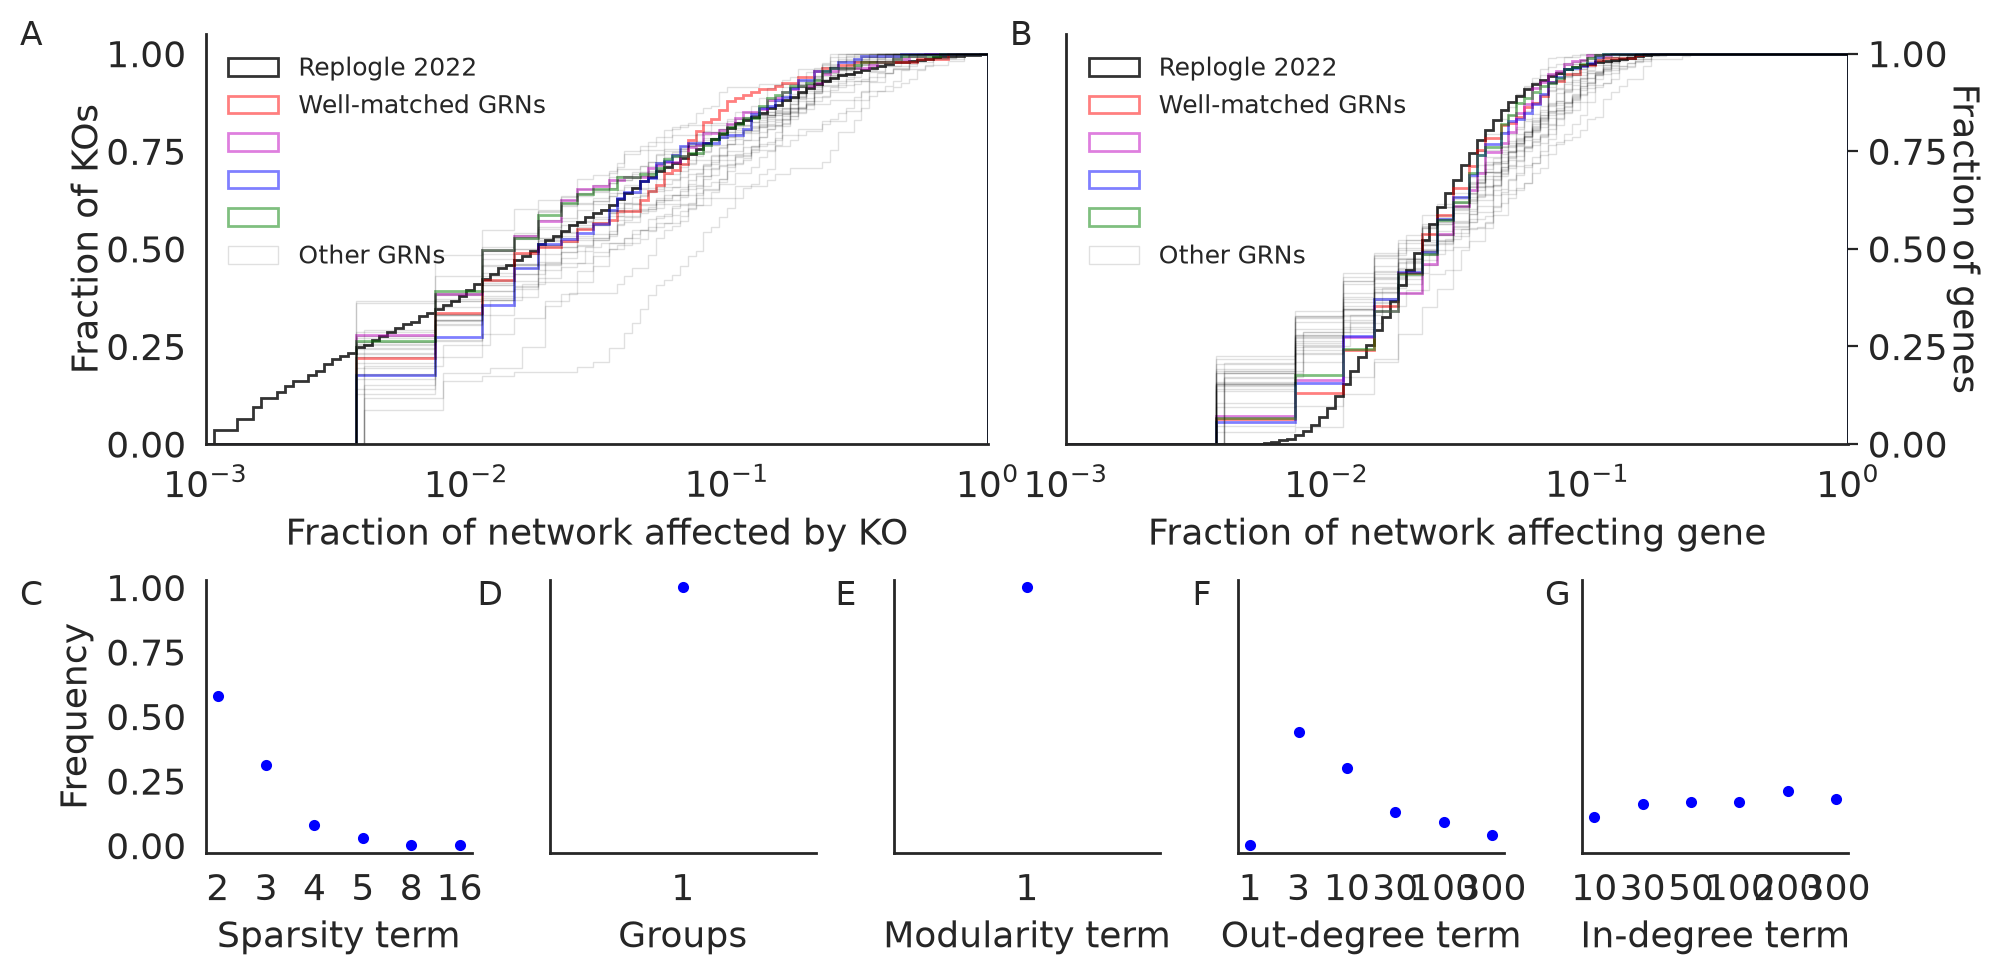

In [9]:
fig = plt.figure(figsize=(10,5), dpi=200)

grid = gs.GridSpec(7, 10, figure=fig)

sns.set_style('white');

# select good grns (closest to data by rank)
k = 4
while (networks[['tg_ks0', 'ko_ks0']].rank(ascending=False) < k).all(axis=1).sum() < 4:
    k += 1
k_good = k
good_grns = networks.loc[(networks[['tg_ks0', 'ko_ks0']].rank(ascending=False) < k_good).all(axis=1),:].sample(4)

# relax to find ok grns (for background distribution)
while (networks[['tg_ks0', 'ko_ks0']].rank(ascending=False) < k).all(axis=1).sum() < 100:
    k += 1
k_ok = k
ok_grns = networks.loc[(networks[['tg_ks0', 'ko_ks0']].rank(ascending=False) < k_ok).all(axis=1),:].sample(100)

# second background distribution 
other_grns = networks.drop(index=good_grns.index).sample(25)

ax = [None for _ in range(7)]
for i,labels in enumerate([{'x':'Fraction of network affected by KO', 'y':'Fraction of KOs', 'col':'ko_array0', 'ps':ps_ko},
                           {'x':'Fraction of network affecting gene', 'y':'Fraction of genes', 'col':'tg_array0', 'ps':ps_tg}]):
    ax[i] = fig.add_subplot(grid[:-3,(5*i):(5*(i+1))])
    for sim in range(1):
        _, bins, _ = ax[i].hist(labels['ps'],
                                alpha=0.8,
                                color='k',
                                histtype='step',
                                bins=np.logspace(-3,0,100),
                                cumulative=1,
                                density=1,
                                label='Replogle 2022' if sim==0 else '')

    for n,ix in enumerate(good_grns.index):
        ax[i].hist(networks.loc[ix, labels['col']],
                   alpha=0.5,
                   linewidth=1,
                   color='rmbg'[n],
                   histtype='step',
                   bins=bins, 
                   cumulative=1, 
                   density=1,
                   label='Well-matched GRNs' if n==0 else ' ')

    for n,ix in enumerate(other_grns.index): #
        ax[i].hist(networks.loc[ix, labels['col']],
                   alpha=0.12,
                   linewidth=0.5,
                   color='k',
                   histtype='step',
                   bins=bins, 
                   cumulative=1, 
                   density=1,
                   label='Other GRNs' if n==0 else '')    

    ax[i].legend(fontsize='x-small', loc='upper left', frameon=False)
    ax[i].semilogx();
    ax[i].set_xlim(1e-3, 1);
    ax[i].set_xlabel(labels['x'])
    ax[i].set_ylabel(labels['y'], rotation=90 if i==0 else 270, labelpad=0 if i==0 else 12)
    if i==1:
        ax[i].yaxis.tick_right();
        ax[i].yaxis.set_label_position('right');

for i,(stat,label) in enumerate(zip(['r','k','w','delta_out','delta_in'],
                                    ['Sparsity term','Groups','Modularity term','Out-degree term', 'In-degree term'])):
    ax[i+2] = fig.add_subplot(grid[-3:,(2*i):(2*(i+1))])

    pct=True
    freqs = dict(ok_grns[stat].value_counts()/(ok_grns.shape[0] if pct else 1.))
    xvals = networks[stat].unique()
    ax[i+2].plot(np.arange(len(xvals)), [freqs.get(x, 0) for x in xvals], 'b.');
    if i==0:
        ax[i+2].set_ylabel('Frequency' if pct else 'No. of GRNs');
    else:
        ax[i+2].set_yticklabels([]);
    ax[i+2].set_ylim(np.array([-0.03, 1.03])*(1 if pct else ok_grns.shape[0]));
    ax[i+2].set_yticks([f if pct else int(f*ok_grns.shape[0]) for f in [0, 0.25, 0.5, 0.75, 1]]);
    ax[i+2].set_xlabel(label);
    ax[i+2].set_xticks(np.arange(len(xvals)));
    ax[i+2].set_xticklabels(map(str, xvals));
    ax[i+2].set_in_layout(False)

sns.despine()
fig.tight_layout(h_pad=0.6, w_pad=0.1);

if True:
    fig.text(0, 0.95, 'A', fontsize=12);
    fig.text(0.495, 0.95, 'B', fontsize=12);
    fig.text(0, 0.39, 'C', fontsize=12);
    fig.text(0.18+0.055, 0.39, 'D', fontsize=12, horizontalalignment='center');
    fig.text(0.358+0.055, 0.39, 'E', fontsize=12, horizontalalignment='center');
    fig.text(0.536+0.055, 0.39, 'F', fontsize=12, horizontalalignment='center');
    fig.text(0.714+0.055, 0.39, 'G', fontsize=12, horizontalalignment='center');
    plt.savefig('png/fig5.png');

## Alternate Version

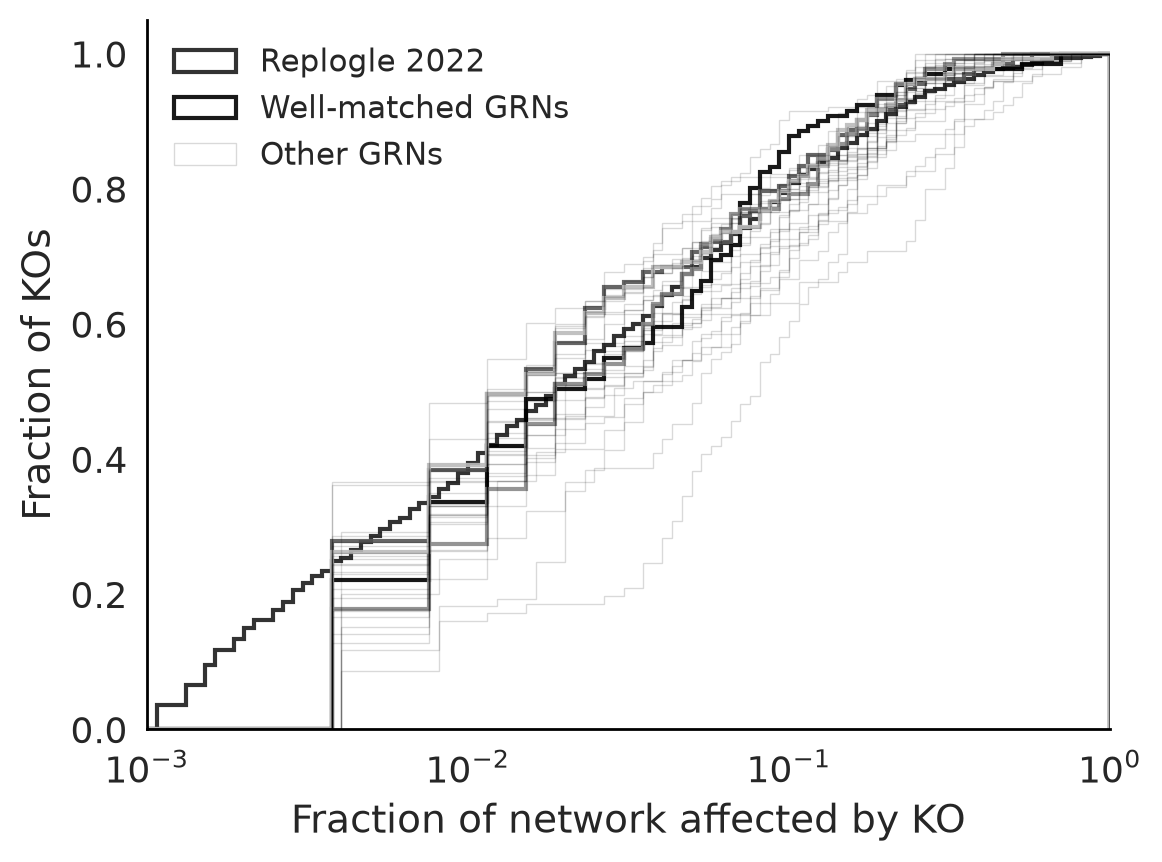

Saved: fig5_ko_histogram.png


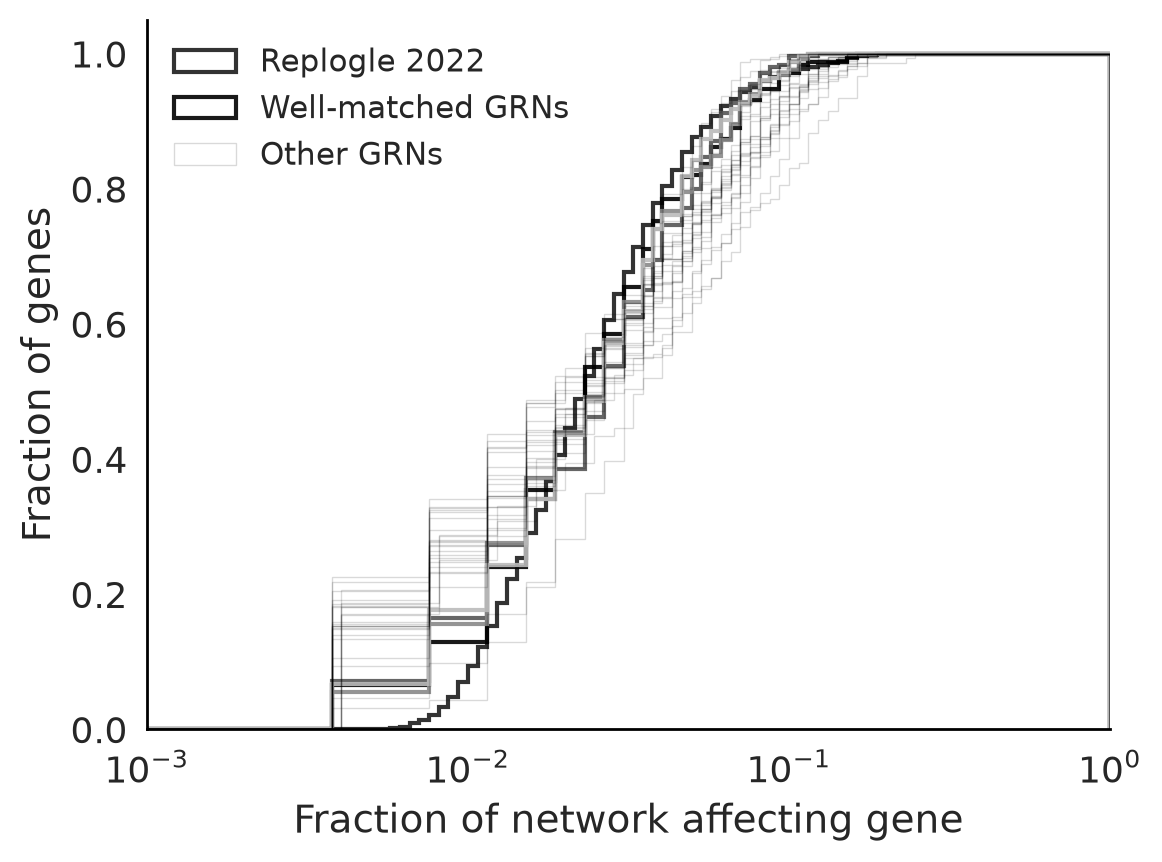

Saved: fig5_tg_histogram.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global styling: DejaVu Sans and larger text
plt.rcParams.update({
    'font.size': 13,
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0
})

# Grayscale shades for the well-matched GRNs
gray_palette = ['black', '#555555', '#888888', '#bbbbbb']

hist_configs = [
    {
        'x': 'Fraction of network affected by KO',
        'y': 'Fraction of KOs',
        'col': 'ko_array0',
        'ps': ps_ko,
        'filename': 'fig5_ko_histogram.png'
    },
    {
        'x': 'Fraction of network affecting gene',
        'y': 'Fraction of genes',
        'col': 'tg_array0',
        'ps': ps_tg,
        'filename': 'fig5_tg_histogram.png'
    }
]

for config in hist_configs:
    fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200)

    # 1. Replogle 2022 (True data)
    _, bins, _ = ax.hist(
        config['ps'], alpha=0.8, color='black', histtype='step',
        bins=np.logspace(-3, 0, 100), cumulative=1, density=1,
        linewidth=1.5, label='Replogle 2022'
    )

    # 2. Well-matched GRNs
    for n, ix in enumerate(good_grns.index):
        ax.hist(
            networks.loc[ix, config['col']], alpha=0.9, linewidth=1.5,
            color=gray_palette[n], histtype='step', bins=bins,
            cumulative=1, density=1,
            label='Well-matched GRNs' if n == 0 else ''
        )

    # 3. Other GRNs (Background distribution)
    for n, ix in enumerate(other_grns.index):
        ax.hist(
            networks.loc[ix, config['col']], alpha=0.15, linewidth=0.5,
            color='black', histtype='step', bins=bins,
            cumulative=1, density=1,
            label='Other GRNs' if n == 0 else ''
        )

    ax.legend(fontsize=11, loc='upper left', frameon=False)
    ax.set_xscale('log')
    ax.set_xlim(1e-3, 1)
    ax.set_xlabel(config['x'], fontsize=14)
    ax.set_ylabel(config['y'], fontsize=14)

    sns.despine(ax=ax)
    fig.tight_layout()

    # Save as individual high-res PNG files
    fig.savefig(config['filename'], dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f"Saved: {config['filename']}")

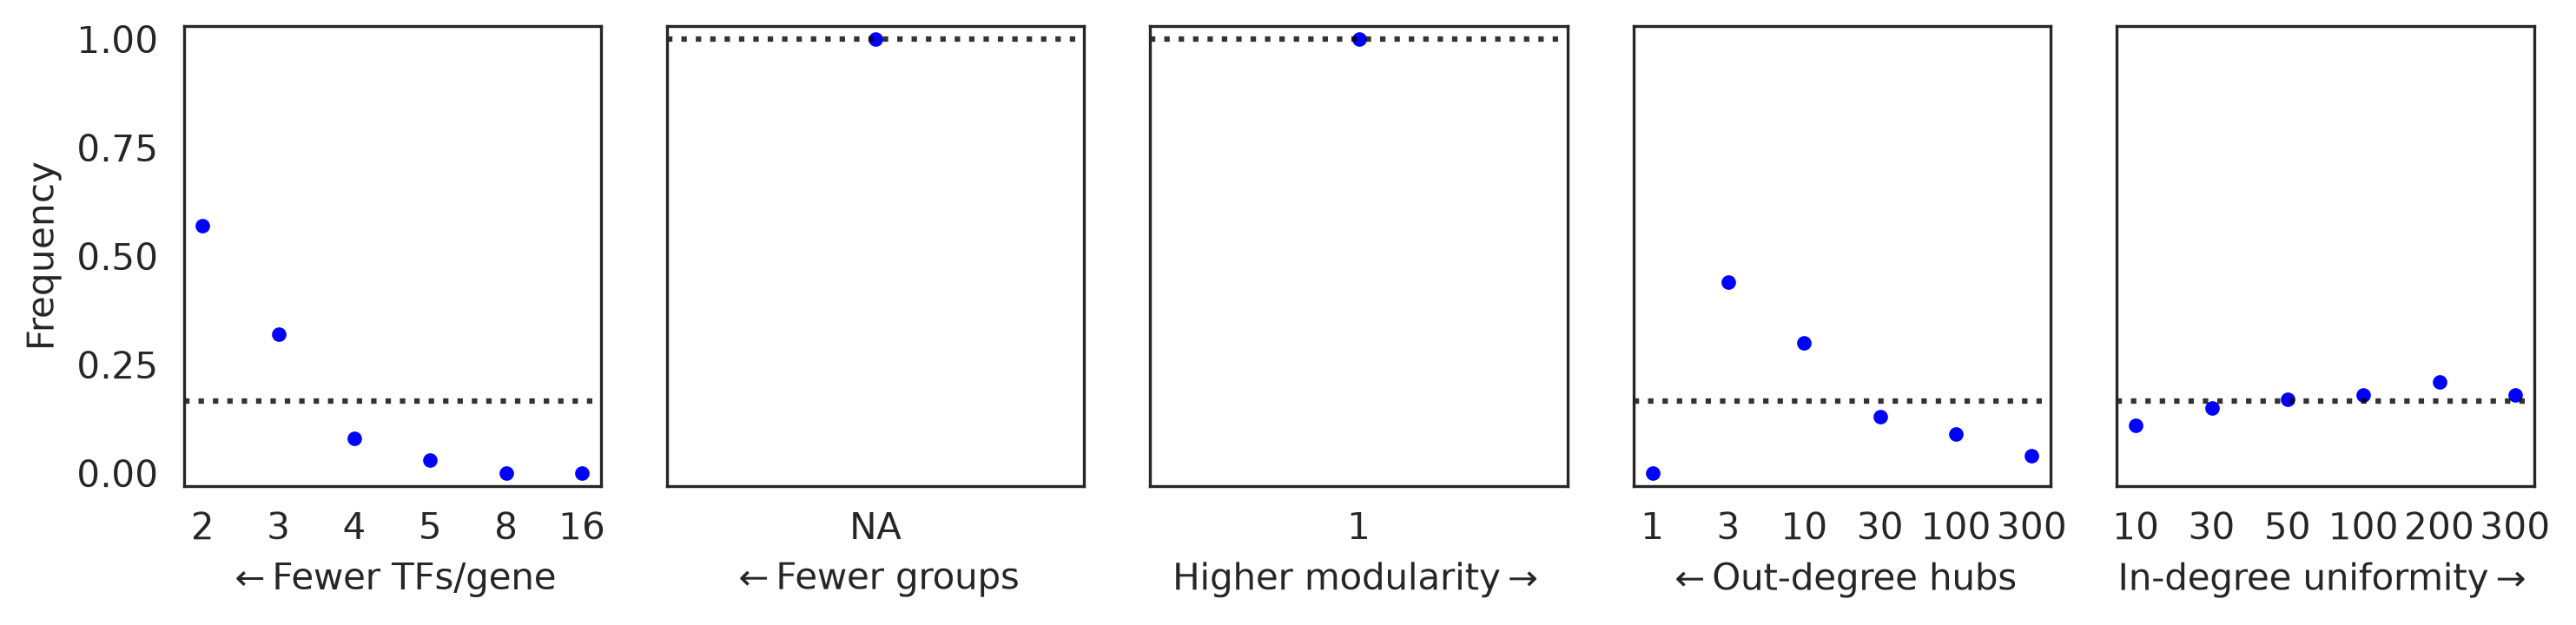

In [30]:
names=[r'$1/p$'+'\n'+r'$\leftarrow$'+' Fewer TFs per gene', 
       '',
       r'$w$'+'\nHigher modularity '+r'$\rightarrow$',
       r'$\delta_{out}$'+'\n'+r'$\leftarrow$'+' More hub regulators',
        r'$\delta_{in}$'+'\nMore Poisson-like in-degree '+r'$\rightarrow$',
]

fig, ax = plt.subplots(1, 5, figsize=(10,2.5), dpi=300);

networks['k_adj'] = networks['k'].replace({1:2000})
ok_grns['k_adj'] = ok_grns['k'].replace({1:2000})

for i,(stat,label) in enumerate(zip(['r','k_adj','w','delta_out','delta_in'],
                                    [r'$\leftarrow$'+'Fewer TFs/gene',
                                     r'$\leftarrow$'+'Fewer groups',
                                a     'Higher modularity'+r'$\rightarrow$',
                                     r'$\leftarrow$'+'Out-degree hubs',
                                     'In-degree uniformity'+r'$\rightarrow$'
                                     ])):
    pct=True
    freqs = dict(ok_grns[stat].value_counts()/(ok_grns.shape[0] if pct else 1.))
    xvals = sorted(networks[stat].unique())
    ax[i].plot(np.arange(len(xvals)), [freqs.get(x, 0) for x in xvals], 'b.');
    if i==0:
        ax[i].set_ylabel('Frequency' if pct else 'No. of GRNs');
    else:
        ax[i].set_yticklabels([]);
    #ax[i+2].yaxis.tick_right();
    #ax[i+2].yaxis.set_label_position('right');
    ax[i].set_ylim(np.array([-0.03, 1.03])*(1 if pct else ok_grns.shape[0]));
    ax[i].set_yticks([f if pct else int(f*ok_grns.shape[0]) for f in [0, 0.25, 0.5, 0.75, 1]]);
    ax[i].set_xlabel(label);
    ax[i].set_xticks(np.arange(len(xvals)));
    ax[i].set_xticklabels([str(x) if x != 2000 else 'NA' for x in xvals]);
    ax[i].axhline((1 if pct else ok_grns.shape[0])/len(xvals), color='k', linestyle=':', alpha=0.8);
    ax[i].set_in_layout(False)

fig.tight_layout()

## Talk version

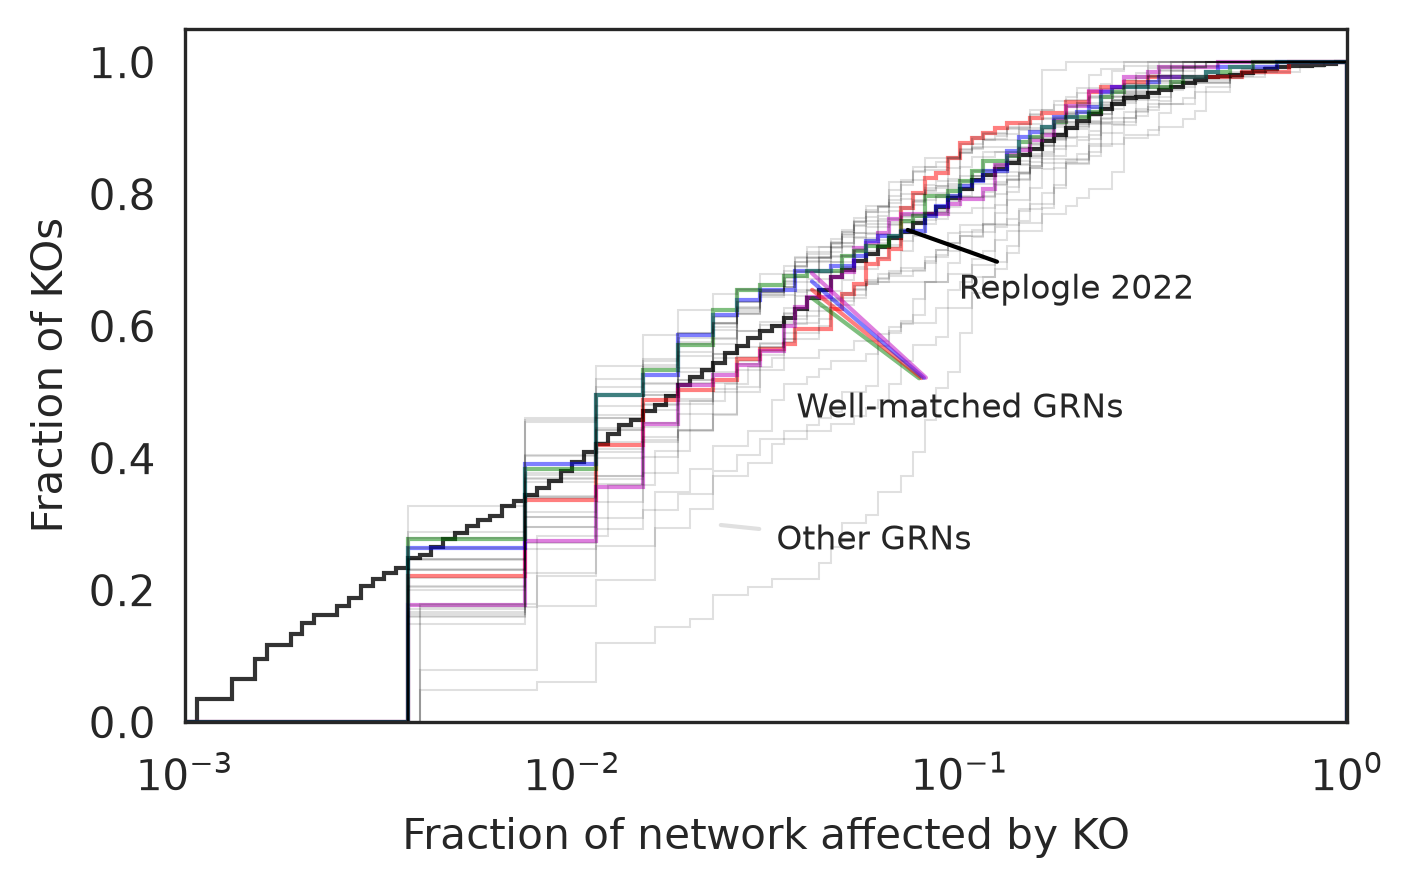

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=300);

for i,labels in enumerate([{'x':'Fraction of network affected by KO', 'y':'Fraction of KOs', 'col':'ko_array0', 'ps':ps_ko}]):
    for sim in range(1):
        _, bins, _ = ax.hist(labels['ps'],
                                alpha=0.8,
                                color='k',
                                histtype='step',
                                bins=np.logspace(-3,0,100),
                                cumulative=1,
                                density=1,
                                label='Replogle 2022' if sim==0 else '')

    for n,ix in enumerate(good_grns.index):
        ax.hist(networks.loc[ix, labels['col']],
                   alpha=0.5,
                   linewidth=1,
                   color='rmbg'[n],
                   histtype='step',
                   bins=bins, 
                   cumulative=1, 
                   density=1,
                   label='Well-matched GRNs' if n==0 else ' ')

    for n,ix in enumerate(other_grns.index): #
        ax.hist(networks.loc[ix, labels['col']],
                   alpha=0.12,
                   linewidth=0.5,
                   color='k',
                   histtype='step',
                   bins=bins, 
                   cumulative=1, 
                   density=1,
                   label='Other GRNs' if n==0 else '')    

    ax.semilogx();
    ax.set_xlim(1e-3, 1);
    ax.set_xlabel(labels['x'])
    ax.set_ylabel(labels['y'])

ax.annotate('Replogle 2022', 
            xy=(0.07,0.75), 
            xytext=(0.2, 0.68), # (2.2, 6e-5), (0.9e-4, 6e-5)
            fontsize=8, va='top', ha='center',
            arrowprops=dict(arrowstyle='-', facecolor='k', edgecolor='k')
            #arrowprops=dict(facecolor='blue', width=1, headlength=0.1, headwidth=0.1, shrink=0.1),
            );

for i,c in enumerate('grbm'):
    ax.annotate('Well-matched GRNs', 
                xy=(0.04,0.65+(0.013*i)), 
                xytext=(0.1, 0.5), # (2.2, 6e-5), (0.9e-4, 6e-5)
                fontsize=8, va='top', ha='center', alpha=0 if i else 1, 
                arrowprops=dict(arrowstyle='-', facecolor=c, edgecolor=c, alpha=0.5)
                #arrowprops=dict(facecolor='blue', width=1, headlength=0.1, headwidth=0.1, shrink=0.1),
                );

ax.annotate('Other GRNs', xy=(0.023,0.3), xytext=(0.06, 0.3), # (2.2, 6e-5), (0.9e-4, 6e-5)
            fontsize=8, va='top', ha='center', 
            arrowprops=dict(arrowstyle='-', facecolor='k', edgecolor='k', alpha=0.12)
            #arrowprops=dict(facecolor='blue', width=1, headlength=0.1, headwidth=0.1, shrink=0.1),
            );

#sns.despine();

# Supplement

## Effect of baseline transcription

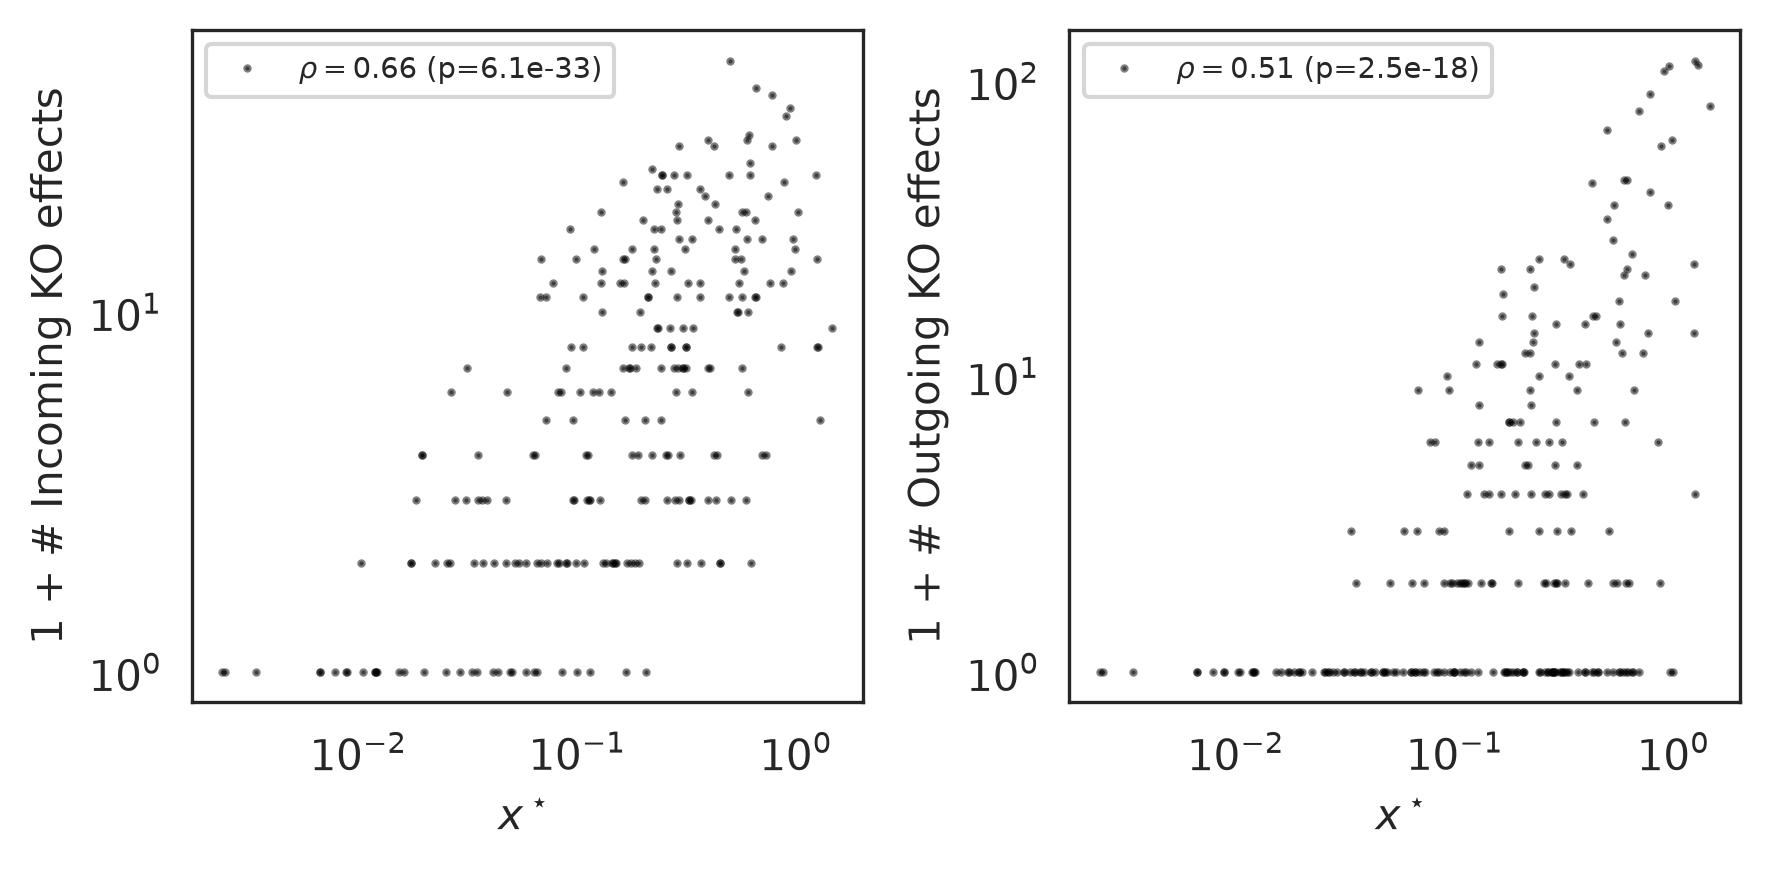

In [32]:
fig, ax = plt.subplots(1,2,figsize=(6,3),dpi=300);

grn=279
for i,yl in enumerate(['Incoming','Outgoing']):
    x = rna[grn,:][~lowE[grn,:]]
    y = (np.abs(ko[grn,:,:][np.ix_(~lowE[grn,:],~lowE[grn,:])]*x) > np.quantile(np.abs(ko[grn,:,:][np.ix_(~lowE[grn,:],~lowE[grn,:])]*x).flatten(), 1-q_ps)).sum(axis=i) + 1
    ax[i].plot(x, y, 'k.', alpha=0.5, ms=2);
    ax[i].loglog();
    ax[i].set_xlabel(r'$x^\star$');
    ax[i].set_ylabel('1 + # {0} KO effects'.format(yl));
    ax[i].legend([r'$\rho=$'+'{0:.2f} (p={1:.1e})'.format(*ss.spearmanr(x,y))], fontsize='x-small');

fig.tight_layout();

In [25]:
networks['in_out_rank_sum'] = networks[['tg_ks0','ko_ks0']].rank(ascending=False).sum(axis=1)
networks['in_out_rank_sum_rank'] = networks['in_out_rank_sum'].rank()
networks.head(2)

,files,n,k,r,delta_in,delta_out,w,config,rep,seed,sweep_id,tg_array0,ko_array0,tg_ks0,ko_ks0,pct_ko,in_out_rank_sum,in_out_rank_sum_rank
network_idx,,,,,,,,,,,,,,,,,,
0,/storage/brno2/home/jiribruthans/grn_files/swe...,256,1,2,10,1,1,1,1,101,1,"[0.06274509803921569, 0.08627450980392157, 0.0...","[0.5411764705882353, 0.0, 0.47843137254901963,...",1.705802e-06,8.042045e-19,0.031449,627.0,161.0
1,/storage/brno2/home/jiribruthans/grn_files/swe...,256,1,2,10,1,1,1,2,102,2,"[0.054901960784313725, 0.050980392156862744, 0...","[0.0, 0.5411764705882353, 0.8823529411764706, ...",2.426934e-18,5.607138e-26,0.031449,1313.0,751.0


AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

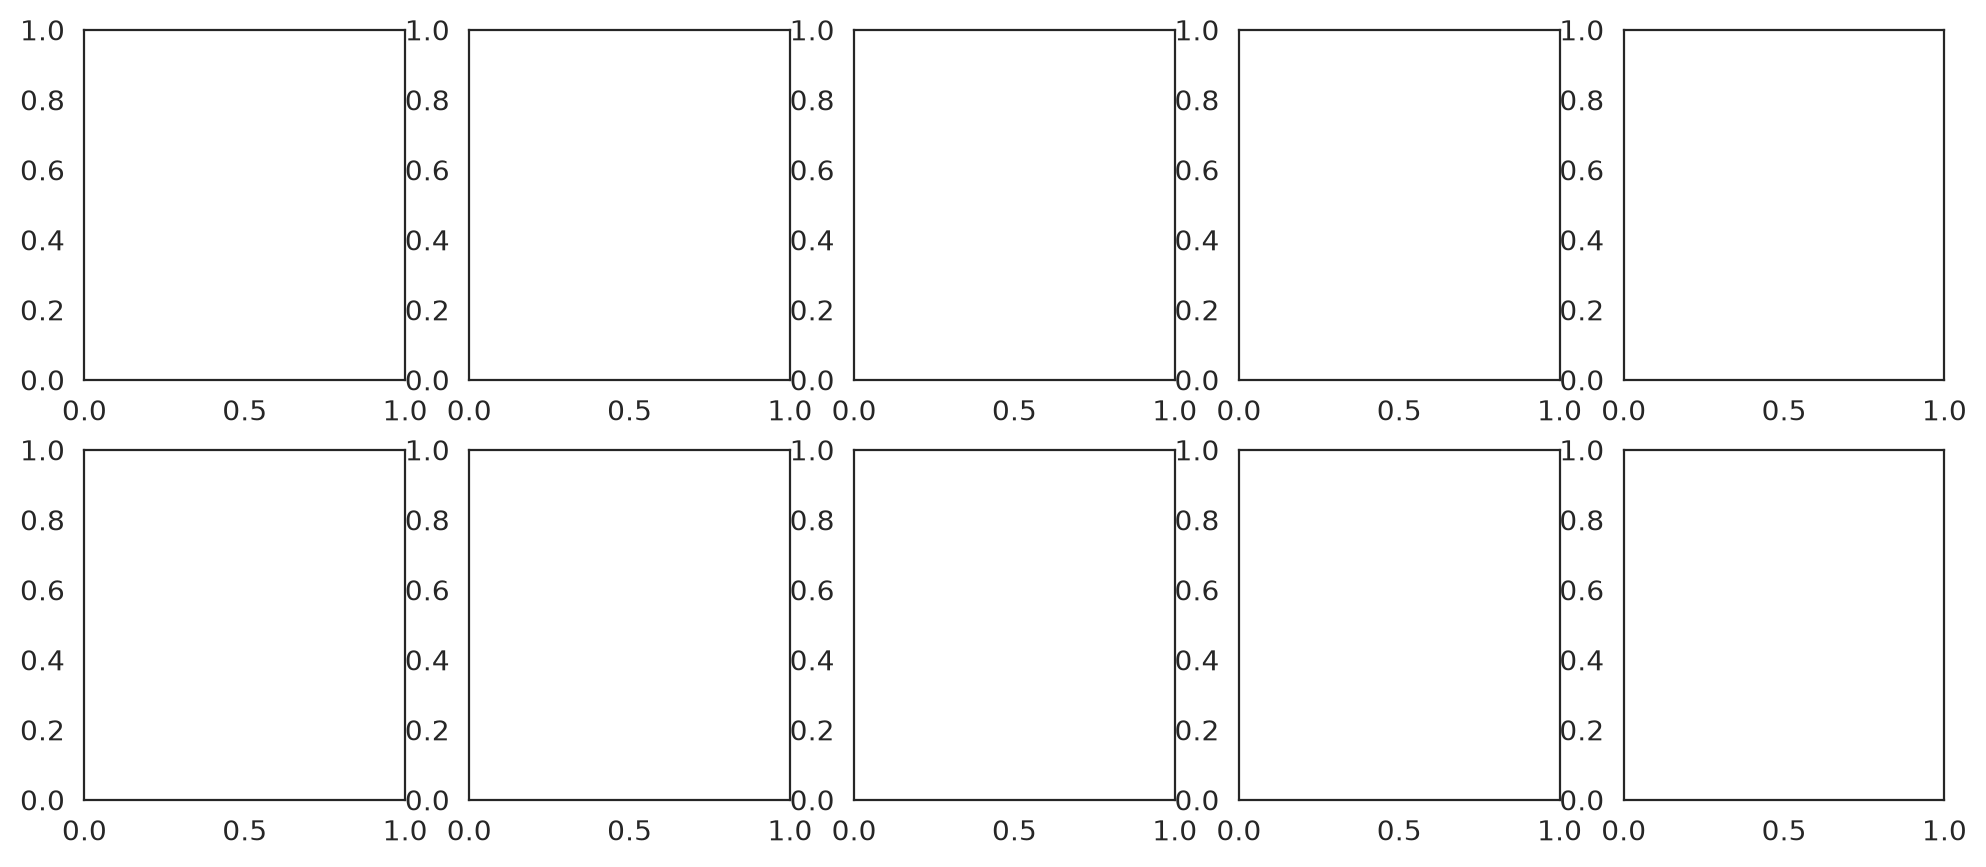

In [26]:
fig, axs = plt.subplots(2, 5, figsize=(12, 5), dpi=200);

a, b = networks['in_out_rank_sum_rank'].quantile((0,1)).values

labels = {'r':'Sparsity term', 
          'k':'No. groups', 
          'w':'Modularity term', 
          'delta_in':'In-degree term', 
          'delta_out':'Out-degree term'}

for i,(xc,yc) in enumerate(itertools.combinations(['r','k','w','delta_in','delta_out'], 2)):
    ax = axs.T[i // 2, i % 2]
    xvals = dict(map(reversed,enumerate(networks[xc].unique())))
    yvals = dict(map(reversed,enumerate(networks[yc].unique())))
    for _,(x,y,c) in networks[[xc, yc, 'in_out_rank_sum_rank']].sort_values('in_out_rank_sum_rank', ascending=False).iterrows():
        j = 0.2
        ax.plot(xvals[x] + j*np.random.uniform(-1, 1),
                yvals[y] + j*np.random.uniform(-1, 1),
                '.', ms=1, alpha=0.9,
                color=plt.cm.get_cmap('RdBu')(0.1 + 0.8*(c-a)/(b-a)))
    ax.set_xlabel(labels[xc]);
    ax.set_ylabel(labels[yc]);
    ax.set_xticks(range(len(xvals)));
    ax.set_xticklabels(list(xvals.keys()));
    ax.set_yticks(range(len(yvals)));
    ax.set_yticklabels(list(yvals.keys()));

fig.tight_layout();
plt.savefig('png/supplement/fig_s5a.png');
plt.show()

In [33]:
networks.loc[good_grns.index]

,files,n,k,r,delta_in,delta_out,w,config,rep,seed,sweep_id,tg_array0,ko_array0,tg_ks0,ko_ks0,pct_ko,in_out_rank_sum,in_out_rank_sum_rank,k_adj
network_idx,,,,,,,,,,,,,,,,,,,
229,/storage/brno2/home/jiribruthans/grn_files/swe...,256,1,3,100,3,1,46,5,4605,230,"[0.043137254901960784, 0.03137254901960784, 0....","[0.0, 0.19607843137254902, 0.17254901960784313...",0.000063,8.227605e-09,0.031449,91.5,5.0,2000
50,/storage/brno2/home/jiribruthans/grn_files/swe...,256,1,2,200,3,1,11,1,1101,51,"[0.10980392156862745, 0.08235294117647059, 0.0...","[0.25882352941176473, 0.30980392156862746, 0.2...",0.000003,2.236072e-08,0.031449,88.5,2.0,2000
45,/storage/brno2/home/jiribruthans/grn_files/swe...,256,1,2,100,3,1,10,1,1001,46,"[0.027450980392156862, 0.047058823529411764, 0...","[0.6745098039215687, 0.10980392156862745, 0.34...",0.000006,3.706166e-08,0.031449,71.0,1.0,2000
48,/storage/brno2/home/jiribruthans/grn_files/swe...,256,1,2,100,3,1,10,4,1004,49,"[0.0196078431372549, 0.12549019607843137, 0.04...","[0.4470588235294118, 0.10980392156862745, 0.23...",0.000002,3.706166e-08,0.031449,92.5,6.0,2000


In [27]:
for stat in ['r','k','w','delta_in','delta_out']:
    print(networks.sort_values('in_out_rank_sum').head(100)[stat].value_counts())

r
2    53
3    34
4    10
5     2
8     1
Name: count, dtype: int64
k
1    100
Name: count, dtype: int64
w
1    100
Name: count, dtype: int64
delta_in
300    21
100    19
200    19
50     16
30     13
10     12
Name: count, dtype: int64
delta_out
3      46
10     29
30     10
300     8
100     4
1       3
Name: count, dtype: int64


In [36]:
networks['in_out_rank_sum'] = (
    networks[['tg_ks0', 'ko_ks0']]
    .rank(ascending=False)
    .sum(axis=1)
)

good_grns = networks.nsmallest(10, 'in_out_rank_sum')

display(good_grns[
    ['r', 'delta_in', 'delta_out',
     'tg_ks0', 'ko_ks0', 'in_out_rank_sum']
])

,r,delta_in,delta_out,tg_ks0,ko_ks0,in_out_rank_sum
network_idx,,,,,,
45,2,100,3,5.919656e-06,3.706166e-08,71.0
50,2,200,3,3.476469e-06,2.236072e-08,88.5
37,2,30,3,1.420068e-02,2.212440e-09,90.0
44,2,50,3,1.247057e-02,2.212440e-09,91.0
229,3,100,3,6.273447e-05,8.227605e-09,91.5
48,2,100,3,1.657986e-06,3.706166e-08,92.5
54,2,200,3,1.089332e-04,3.786423e-09,102.0
33,2,10,3,1.595886e-06,1.620884e-08,120.5
230,3,200,3,8.573428e-07,1.759951e-08,121.0
